# Profile Interpolation Analysis

Compares the raw in-situ effective radius profiles (17–103 altitude levels, variable per file)
against the 10-level interpolated versions that will be used as training targets.

Reads directly from the `.mat` files — no HDF5 required.

**Profile convention throughout**: index 0 = cloud top (highest altitude), index -1 = cloud base.

In [5]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

In [6]:
# ── Configuration ──────────────────────────────────────────────────────────────
MAT_DIR   = Path('/Volumes/My Passport/neural_network_training_data/saz0_allProfiles/')
N_LEVELS  = 10   # number of interpolated levels used as training target

mat_files = sorted(f for f in MAT_DIR.glob('*.mat')
                   if not f.name.startswith('._'))
print(f'Found {len(mat_files)} .mat files')

Found 73 .mat files


In [7]:
def interpolate_profile(re_raw, z_raw, n_levels_out):
    """
    Interpolate a variable-length r_e profile to n_levels_out evenly-spaced
    altitude levels using the actual altitude coordinates in z_raw.

    Parameters
    ----------
    re_raw : (n,)  effective radius, cloud top → base (μm)
    z_raw  : (n,)  altitude, cloud top → base (km, decreasing)
    n_levels_out : int

    Returns
    -------
    re_interp : (n_levels_out,)  — cloud top → base
    z_interp  : (n_levels_out,)  — evenly-spaced altitudes, cloud top → base (km)
    """
    z_asc  = z_raw[::-1]   # ascending: cloud base → top
    re_asc = re_raw[::-1]
    z_target_asc = np.linspace(z_asc[0], z_asc[-1], n_levels_out)
    re_interp_asc = np.interp(z_target_asc, z_asc, re_asc)
    return re_interp_asc[::-1], z_target_asc[::-1]  # flip back: top → base

In [8]:
# ── Load all profiles ──────────────────────────────────────────────────────────
profiles_raw  = []   # list of (n_i,) arrays, variable length
altitudes_raw = []   # corresponding z arrays
profiles_10   = []   # (N_LEVELS,) interpolated
altitudes_10  = []   # (N_LEVELS,) evenly-spaced altitude grid
tau_c_all     = []

for path in mat_files:
    d = scipy.io.loadmat(path, squeeze_me=True)
    re = d['re'].astype(np.float64)
    z  = d['z'].astype(np.float64)
    tau_c = float(d['tau'][-1])

    re_10, z_10 = interpolate_profile(re, z, N_LEVELS)

    profiles_raw.append(re)
    altitudes_raw.append(z)
    profiles_10.append(re_10)
    altitudes_10.append(z_10)
    tau_c_all.append(tau_c)

n_profiles = len(profiles_raw)
n_levels_each = np.array([len(r) for r in profiles_raw])
tau_c_all = np.array(tau_c_all)

print(f'Loaded {n_profiles} profiles')
print(f'Profile lengths: min={n_levels_each.min()}, max={n_levels_each.max()}, mean={n_levels_each.mean():.1f}')
print(f'tau_c range: [{tau_c_all.min():.1f}, {tau_c_all.max():.1f}]')

Loaded 73 profiles
Profile lengths: min=17, max=103, mean=48.1
tau_c range: [0.0, 34.3]


## 1. Profile length distribution

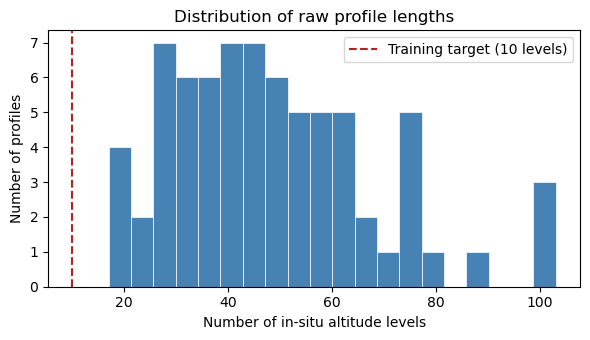

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(n_levels_each, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(N_LEVELS, color='firebrick', linewidth=1.5, linestyle='--',
           label=f'Training target ({N_LEVELS} levels)')
ax.set_xlabel('Number of in-situ altitude levels')
ax.set_ylabel('Number of profiles')
ax.set_title('Distribution of raw profile lengths')
ax.legend()
fig.tight_layout()
plt.show()

## 2. Individual profile comparisons

Gray line with dots: raw in-situ measurement at full resolution.  
Colored line with filled circles: 10-level interpolated version (the training target).  
Profiles are sorted by number of raw levels (fewest → most) so you can see how interpolation quality scales with resolution.

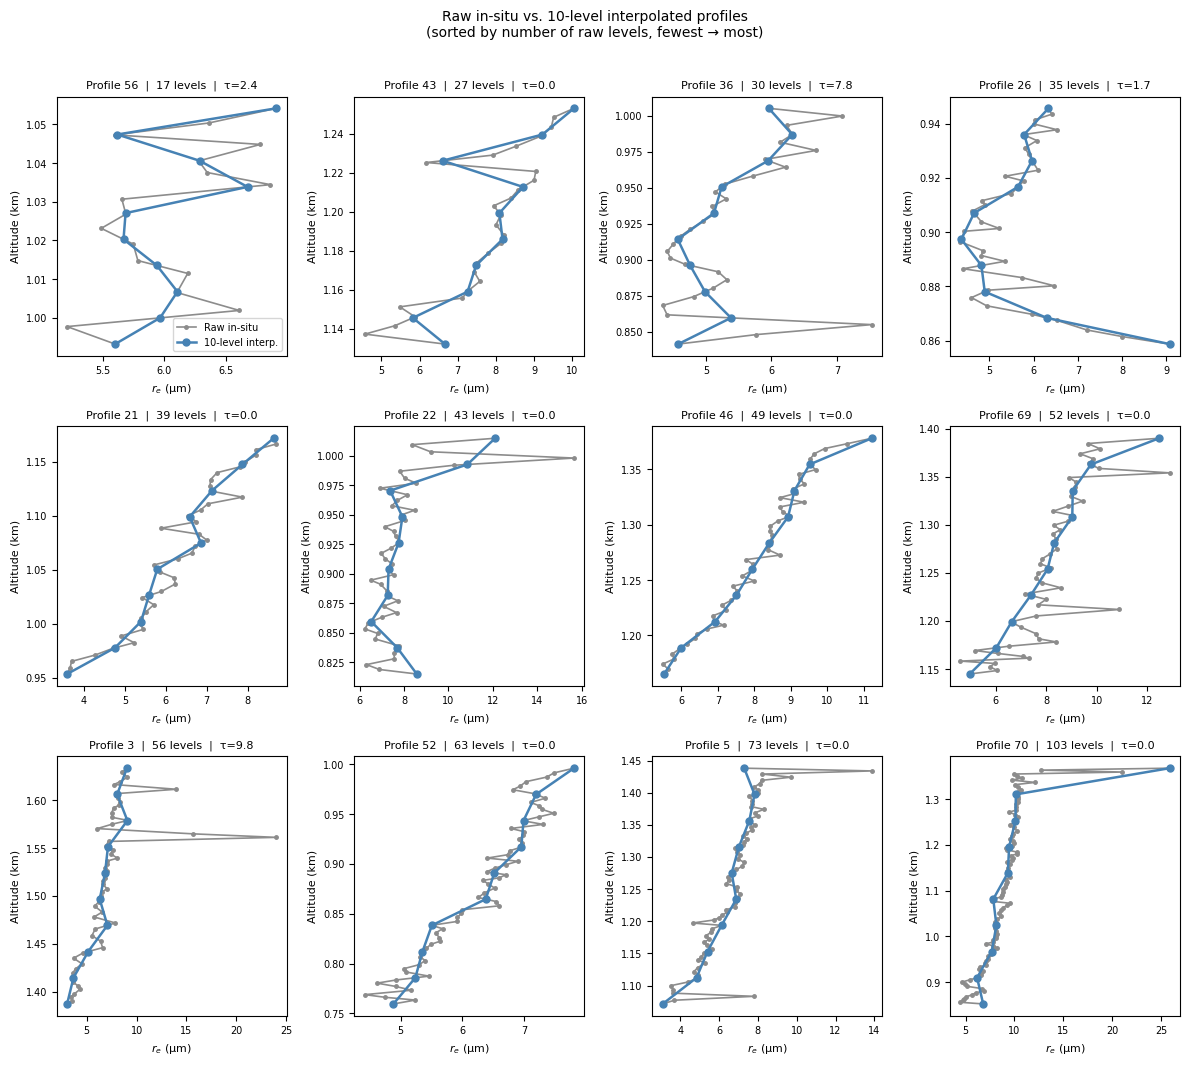

In [10]:
# Sort profiles by number of raw levels so the grid shows a range of complexities
sort_idx = np.argsort(n_levels_each)

# Pick N_SHOW profiles spaced evenly through the sorted list
N_SHOW = 12
show_idx = sort_idx[np.linspace(0, n_profiles - 1, N_SHOW, dtype=int)]

ncols = 4
nrows = int(np.ceil(N_SHOW / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 3.5),
                         sharey=False, sharex=False)
axes = axes.flatten()

for ax, idx in zip(axes, show_idx):
    re_raw = profiles_raw[idx]
    z_raw  = altitudes_raw[idx]
    re_10  = profiles_10[idx]
    z_10   = altitudes_10[idx]

    # Raw profile
    ax.plot(re_raw, z_raw, color='0.55', linewidth=1.2,
            marker='o', markersize=2.5, label='Raw in-situ')

    # Interpolated profile
    ax.plot(re_10, z_10, color='steelblue', linewidth=1.8,
            marker='o', markersize=5, label=f'{N_LEVELS}-level interp.')

    n_lev = n_levels_each[idx]
    ax.set_title(f'Profile {idx+1}  |  {n_lev} levels  |  τ={tau_c_all[idx]:.1f}',
                 fontsize=8)
    ax.set_xlabel('$r_e$ (μm)', fontsize=8)
    ax.set_ylabel('Altitude (km)', fontsize=8)
    ax.tick_params(labelsize=7)

# Add a shared legend in the first panel
axes[0].legend(fontsize=7, loc='lower right')

# Hide any unused subplots
for ax in axes[N_SHOW:]:
    ax.set_visible(False)

fig.suptitle('Raw in-situ vs. 10-level interpolated profiles\n'
             '(sorted by number of raw levels, fewest → most)',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

## 3. Interpolation error quantification

To measure how well the 10-level profile represents the original, we upsample the 10-level
version back onto the original altitude grid and compare to the raw measurements.  
This gives a per-profile root-mean-squared error (RMSE) and maximum absolute error.

In [11]:
rmse_all = np.zeros(n_profiles)
mae_all  = np.zeros(n_profiles)
maxerr_all = np.zeros(n_profiles)

for i in range(n_profiles):
    re_raw = profiles_raw[i]
    z_raw  = altitudes_raw[i]
    re_10  = profiles_10[i]
    z_10   = altitudes_10[i]

    # Upsample the 10-level profile back to the original z grid
    # (linear interpolation in altitude, same as the forward step)
    z_10_asc   = z_10[::-1]
    re_10_asc  = re_10[::-1]
    z_raw_asc  = z_raw[::-1]
    re_reconstructed_asc = np.interp(z_raw_asc, z_10_asc, re_10_asc)
    re_reconstructed = re_reconstructed_asc[::-1]

    err = re_reconstructed - re_raw
    rmse_all[i]   = np.sqrt(np.mean(err**2))
    mae_all[i]    = np.mean(np.abs(err))
    maxerr_all[i] = np.max(np.abs(err))

print(f'Interpolation error (10-level → reconstructed on raw grid vs. raw):')
print(f'  RMSE:      mean={rmse_all.mean():.3f}  max={rmse_all.max():.3f}  μm')
print(f'  MAE:       mean={mae_all.mean():.3f}  max={mae_all.max():.3f}  μm')
print(f'  Max error: mean={maxerr_all.mean():.3f}  max={maxerr_all.max():.3f}  μm')

Interpolation error (10-level → reconstructed on raw grid vs. raw):
  RMSE:      mean=1.074  max=4.015  μm
  MAE:       mean=0.543  max=1.484  μm
  Max error: mean=4.841  max=20.940  μm


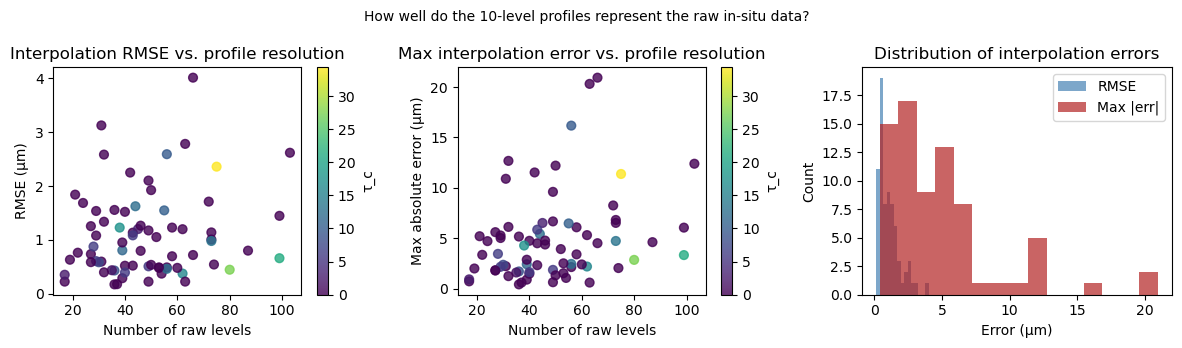

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# RMSE vs. number of raw levels
sc = axes[0].scatter(n_levels_each, rmse_all, c=tau_c_all,
                     cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='τ_c')
axes[0].set_xlabel('Number of raw levels')
axes[0].set_ylabel('RMSE (μm)')
axes[0].set_title('Interpolation RMSE vs. profile resolution')

# Max absolute error vs. number of raw levels
sc2 = axes[1].scatter(n_levels_each, maxerr_all, c=tau_c_all,
                      cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc2, ax=axes[1], label='τ_c')
axes[1].set_xlabel('Number of raw levels')
axes[1].set_ylabel('Max absolute error (μm)')
axes[1].set_title('Max interpolation error vs. profile resolution')

# Error distributions
axes[2].hist(rmse_all,    bins=15, alpha=0.7, label='RMSE',     color='steelblue')
axes[2].hist(maxerr_all,  bins=15, alpha=0.7, label='Max |err|', color='firebrick')
axes[2].set_xlabel('Error (μm)')
axes[2].set_ylabel('Count')
axes[2].set_title('Distribution of interpolation errors')
axes[2].legend()

fig.suptitle('How well do the 10-level profiles represent the raw in-situ data?',
             fontsize=10)
fig.tight_layout()
plt.show()

## 4. All profiles — overview

Raw profiles (gray) and 10-level interpolated profiles (colored by τ_c) plotted together.
Altitude is normalized to cloud fraction (0 = cloud base, 1 = cloud top)
so that profiles of different geometric thickness can be overlaid.

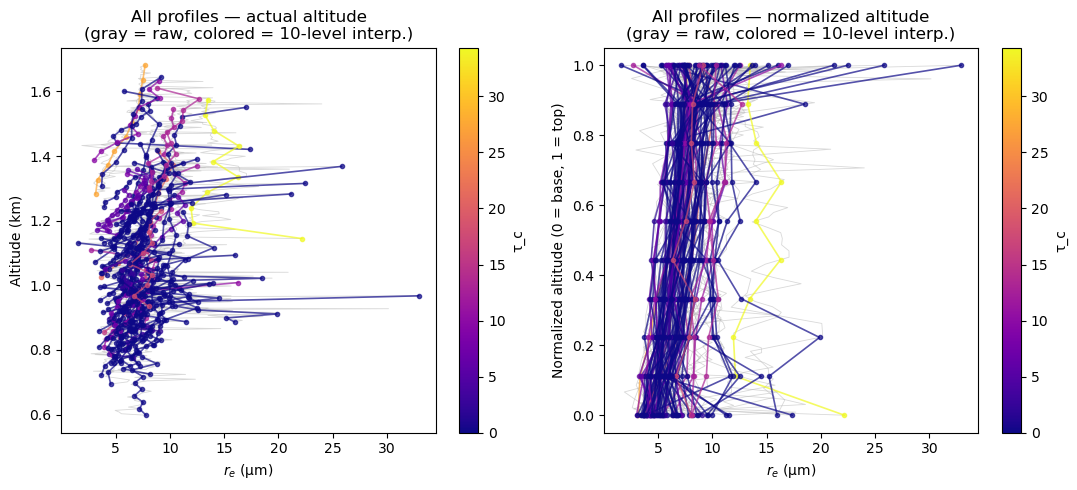

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)

cmap  = plt.get_cmap('plasma')
tau_norm = (tau_c_all - tau_c_all.min()) / (tau_c_all.max() - tau_c_all.min())

# Left: actual altitude (km) — profiles will not overlap perfectly because
# clouds are at different altitudes
for i in range(n_profiles):
    axes[0].plot(profiles_raw[i], altitudes_raw[i],
                 color='0.7', linewidth=0.6, alpha=0.5)
for i in range(n_profiles):
    axes[0].plot(profiles_10[i], altitudes_10[i],
                 color=cmap(tau_norm[i]), linewidth=1.2,
                 marker='o', markersize=3, alpha=0.7)

sm = plt.cm.ScalarMappable(cmap='plasma',
     norm=plt.Normalize(tau_c_all.min(), tau_c_all.max()))
plt.colorbar(sm, ax=axes[0], label='τ_c')
axes[0].set_xlabel('$r_e$ (μm)')
axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('All profiles — actual altitude\n(gray = raw, colored = 10-level interp.)')

# Right: normalized altitude (cloud fraction), so all profiles overlay
for i in range(n_profiles):
    z = altitudes_raw[i]
    z_frac = (z - z[-1]) / (z[0] - z[-1])   # 0 at base, 1 at top
    axes[1].plot(profiles_raw[i], z_frac,
                 color='0.7', linewidth=0.6, alpha=0.5)

for i in range(n_profiles):
    z10 = altitudes_10[i]
    z10_frac = (z10 - z10[-1]) / (z10[0] - z10[-1])
    axes[1].plot(profiles_10[i], z10_frac,
                 color=cmap(tau_norm[i]), linewidth=1.2,
                 marker='o', markersize=3, alpha=0.7)

plt.colorbar(sm, ax=axes[1], label='τ_c')
axes[1].set_xlabel('$r_e$ (μm)')
axes[1].set_ylabel('Normalized altitude (0 = base, 1 = top)')
axes[1].set_title('All profiles — normalized altitude\n(gray = raw, colored = 10-level interp.)')

fig.tight_layout()
plt.show()

## 5. Worst-case profiles

Show the profiles where interpolation error (RMSE) is highest,
so you can inspect whether the 10-level representation misses important structure.

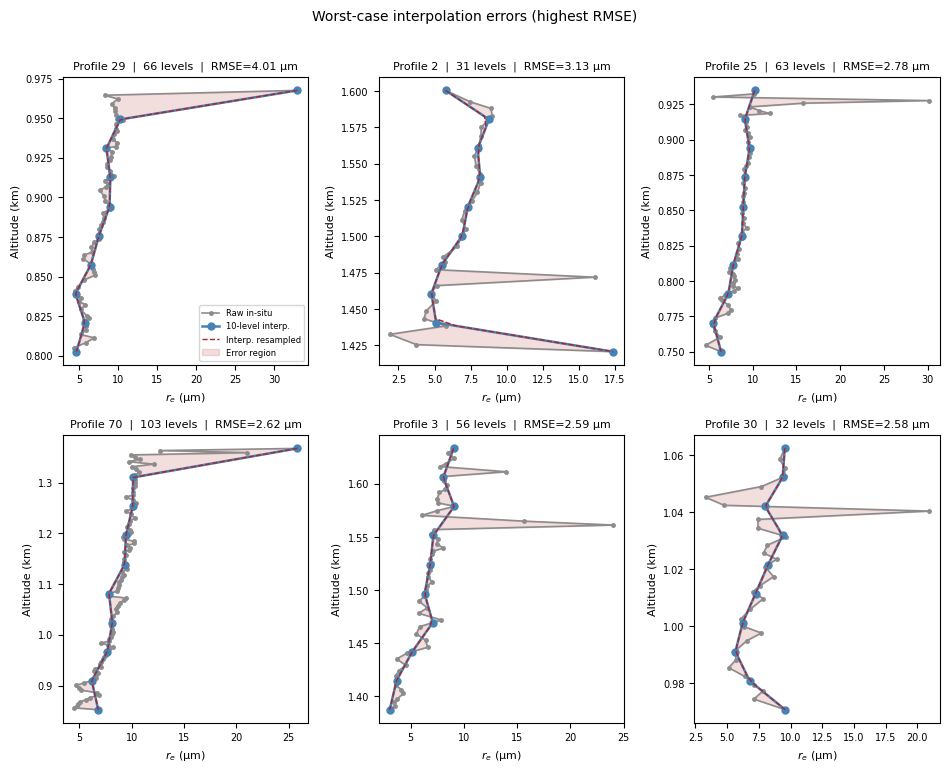

In [14]:
N_WORST = 6
worst_idx = np.argsort(rmse_all)[-N_WORST:][::-1]   # highest RMSE first

ncols = 3
nrows = int(np.ceil(N_WORST / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.8))
axes = axes.flatten()

for ax, idx in zip(axes, worst_idx):
    re_raw = profiles_raw[idx]
    z_raw  = altitudes_raw[idx]
    re_10  = profiles_10[idx]
    z_10   = altitudes_10[idx]

    # Reconstructed profile upsampled back to raw grid (for error overlay)
    z_10_asc  = z_10[::-1]
    re_10_asc = re_10[::-1]
    z_raw_asc = z_raw[::-1]
    re_recon_asc = np.interp(z_raw_asc, z_10_asc, re_10_asc)
    re_recon = re_recon_asc[::-1]

    ax.plot(re_raw,   z_raw, color='0.55', linewidth=1.2,
            marker='o', markersize=2.5, label='Raw in-situ')
    ax.plot(re_10,    z_10,  color='steelblue', linewidth=1.8,
            marker='o', markersize=5, label='10-level interp.')
    ax.plot(re_recon, z_raw, color='firebrick', linewidth=1.0,
            linestyle='--', label='Interp. resampled')

    ax.fill_betweenx(z_raw, re_raw, re_recon,
                     alpha=0.15, color='firebrick', label='Error region')

    ax.set_title(f'Profile {idx+1}  |  {n_levels_each[idx]} levels  |  '
                 f'RMSE={rmse_all[idx]:.2f} μm', fontsize=8)
    ax.set_xlabel('$r_e$ (μm)', fontsize=8)
    ax.set_ylabel('Altitude (km)', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=6, loc='best')

for ax in axes[N_WORST:]:
    ax.set_visible(False)

fig.suptitle(f'Worst-case interpolation errors (highest RMSE)',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

## 6. Mean profile and variability

Mean ± 1σ envelope for both the raw profiles (interpolated to a common normalized grid for averaging)
and the 10-level profiles. Shows whether the 10-level representation preserves mean behavior and spread.

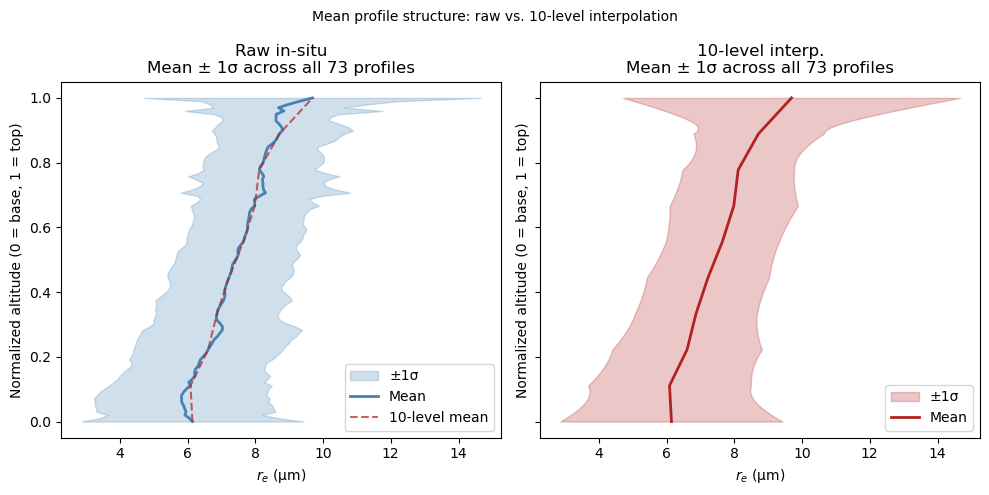

Mean bias (interp - raw) across normalized altitude grid:
  Max absolute bias: 0.738 μm
  Mean absolute bias: 0.108 μm


In [15]:
# Project all profiles onto a common 100-point normalized altitude grid
# so we can compute meaningful statistics across profiles of different thickness
N_COMMON = 100
z_common = np.linspace(0, 1, N_COMMON)   # 0 = cloud base, 1 = cloud top

raw_on_common = np.zeros((n_profiles, N_COMMON))
interp_on_common = np.zeros((n_profiles, N_COMMON))

for i in range(n_profiles):
    z = altitudes_raw[i]
    z_frac_asc = ((z - z[-1]) / (z[0] - z[-1]))[::-1]   # ascending
    re_asc = profiles_raw[i][::-1]
    raw_on_common[i] = np.interp(z_common, z_frac_asc, re_asc)

    z10 = altitudes_10[i]
    z10_frac_asc = ((z10 - z10[-1]) / (z10[0] - z10[-1]))[::-1]
    re10_asc = profiles_10[i][::-1]
    interp_on_common[i] = np.interp(z_common, z10_frac_asc, re10_asc)

raw_mean   = raw_on_common.mean(axis=0)
raw_std    = raw_on_common.std(axis=0)
interp_mean = interp_on_common.mean(axis=0)
interp_std  = interp_on_common.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, mean, std, label, color in [
    (axes[0], raw_mean,    raw_std,    'Raw in-situ',      'steelblue'),
    (axes[1], interp_mean, interp_std, '10-level interp.', 'firebrick'),
]:
    ax.fill_betweenx(z_common, mean - std, mean + std,
                     alpha=0.25, color=color, label='±1σ')
    ax.plot(mean, z_common, color=color, linewidth=2, label='Mean')
    ax.set_xlabel('$r_e$ (μm)')
    ax.set_ylabel('Normalized altitude (0 = base, 1 = top)')
    ax.set_title(f'{label}\nMean ± 1σ across all {n_profiles} profiles')
    ax.legend()

# Overlay comparison
axes[0].plot(interp_mean, z_common, color='firebrick', linewidth=1.5,
             linestyle='--', alpha=0.7, label='10-level mean')
axes[0].legend()

fig.suptitle('Mean profile structure: raw vs. 10-level interpolation', fontsize=10)
fig.tight_layout()
plt.show()

# Quantify bias: does the mean change?
bias = interp_mean - raw_mean
print(f'Mean bias (interp - raw) across normalized altitude grid:')
print(f'  Max absolute bias: {np.abs(bias).max():.3f} μm')
print(f'  Mean absolute bias: {np.abs(bias).mean():.3f} μm')